# <font color="Blue">Using Deep Learning to Conduct Sentiment-based Searching and Analysis of Hotel Reviews on TripAdvisor</font>
#### 3546 - Deep Learning
#### University of Toronto School of Continuing Studies

##### Megan Da Costa, Kashish Verma and Cameron Turner

## <font color="Blue">Project Overview</font>

Travel search platforms such as TripAdvisor utilise millions of reviews and location based information, generating extensive data.

Users seek to use sentiment while querying through location-based data.

Deep Learning and Natural Language Processing can train a machine on meaning behind user searches and present results more closely related to their wants.

Semantic search engines allows for retrieval of contextual data based on meaning.

The goal of this project is to create an engine to search travel data for relevance based on semantic relation.


###<font color="Blue">Application Design</font>

The application design is outlined below.



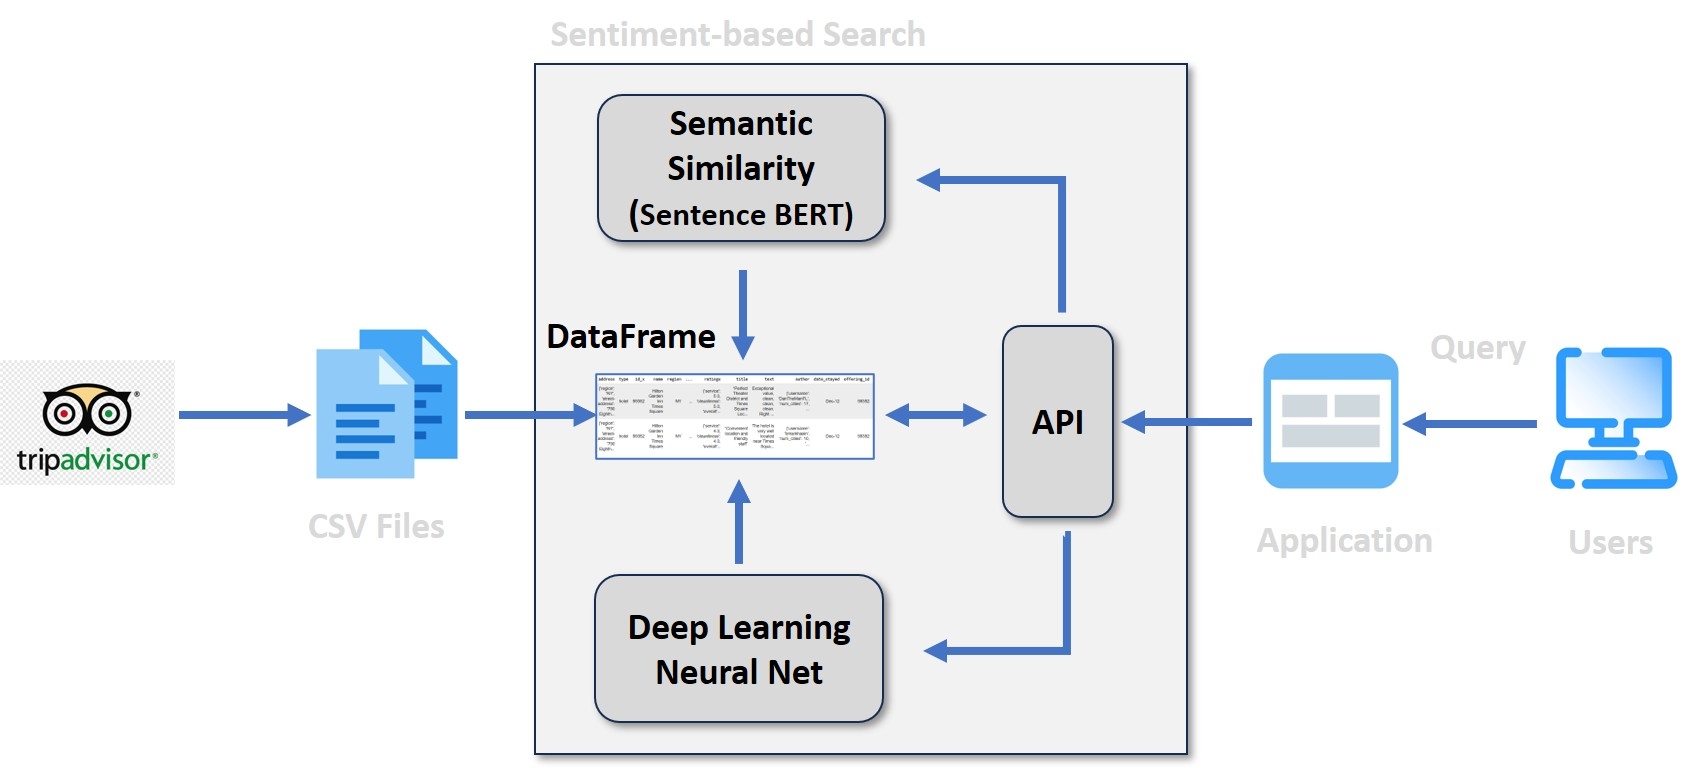

The application design includes components for semantic similarity analysis using Sentence BERT and a deep learning model trained on the pre-computed semantic embeddings / other features against a sentiment classification.

Other review features such as City may have an influence over the review.  For example, a customer's review and overall score may be influenced by a customer's expectations.  A customer may think that a small room in New York City is spacious relatively speaking to a similar room in a smaller city.  Therefore, training a deep learning neural network with the review text as well as other features may increase sentiment accuracy.   

The pipeline:

- Use the review's _overall score_ to create a _positive_ or _negative_ sentiment based on weak supervision (i.e., heuristic).
- Encode the customers' hotel reviews using Sentence BERT.
- Use One-hot Encoding to encode other hotel review features that may influence sentiment.  For this project, it will just be the _city_.
- Train a deep learning neural network on the encoded customer hotel review vector and the city features against the sentiment target.
- The deep learning neural network will follow the pipeline, Train/Test Split → Train Model → Validate → Test → Predict
- Given a search query and city from a user, use the deep learning model to predict its sentiment, filter the results based on predicted sentiment and city then present the best similarity matches to the user.

###<font color="Blue">Dataset</font>

The dataset used in this project is from the following Kaggle dataset:

https://www.kaggle.com/datasets/joebeachcapital/hotel-reviews?select=reviews.csv

The _offerings.csv_ file, which contains the list of hotels, was pre-processed using a Python script to geocode its longitude and latitude geographical coordinates based on the hotel address.  The new file is _all_offerings_with_coordinates.csv_.

## <font color="Blue">Data Loading and Preparation </font>

Let's start the process by loading the input data from the CSV files and preparing it (e.g., cleaning, updating) for developing the text encoding and deep learning model.

In [1]:
# Import libraries.

import ast
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os


In [2]:
# Set testing variables.

_small_scale_testing = False      # Set to True for a CPU processing runtime
_large_scale_testing = False      # Set to True for very large scale data processing


In [3]:
# Mount the drive.

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# Load the data.  The data is in two sets of files:
#
# offerings - the list of hotels
# reviews   - the customer reviews

try:

    file_path = "/content/drive/MyDrive/UT-SCS-3546 - Deep Learning"

    offerings_file = os.path.join(file_path, "all_offerings_with_coordinates.csv")

    # Use the file, reviews_part_1, when processing with a GPU.
    # Use the file, test_reviews_part_1_small, when processing with a CPU.

    reviews1_file = os.path.join(
        file_path,
        "test_reviews_part_1_small.csv" if _small_scale_testing else "reviews_part_1.csv")

    # Load the hotels file.

    dfof = pd.read_csv(offerings_file, skiprows=0, header=0)

    # Load the first review file.

    dfr1 = pd.read_csv(reviews1_file, skiprows=0, header=0)

    # Load in the other reviews files when doing large scale testing.

    dfrf = [dfr1]

    # Future work - each file contains 200K reviews.  Therefore, for large scale
    # testing, it can be tested with a dataset of 800K reviews.

    if _large_scale_testing:

        reviews2_file = os.path.join(file_path, "reviews_part_2.csv")
        reviews3_file = os.path.join(file_path, "reviews_part_3.csv")
        reviews4_file = os.path.join(file_path, "reviews_part_4.csv")

        dfrf.append(pd.read_csv(reviews2_file, skiprows=0, header=0))
        dfrf.append(pd.read_csv(reviews3_file, skiprows=0, header=0))
        dfrf.append(pd.read_csv(reviews4_file, skiprows=0, header=0))

except Exception as ex:

    print("Exception:", ex)

In [5]:
# Concatenate the review files together.

dfr = pd.concat(dfrf, ignore_index=True)

# Merge the two dataframes based on the id and offering_id fields.  Merge as an inner join to keep only ids that match.

df = dfof.merge(dfr, left_on='id', right_on='offering_id')


In [6]:
# Take a peek at what the data looks like.

df.head(2)

,hotel_class,region_id,url,phone,details,address,type,id_x,name,region,...,ratings,title,text,author,date_stayed,offering_id,num_helpful_votes,date,id_y,via_mobile
0,3.5,60763,http://www.tripadvisor.com/Hotel_Review-g60763...,NaN,NaN,"{'region': 'NY', 'street-address': '790 Eighth...",hotel,99352,Hilton Garden Inn Times Square,NY,...,"{'service': 5.0, 'cleanliness': 5.0, 'overall'...",“Perfect Theater District and Times Square Loc...,"Exceptional value, clean, clean, clean. Right ...","{'username': 'DanTheManFL', 'num_cities': 17, ...",Dec-12,99352,0,2012-12-19,147762756,False
1,3.5,60763,http://www.tripadvisor.com/Hotel_Review-g60763...,NaN,NaN,"{'region': 'NY', 'street-address': '790 Eighth...",hotel,99352,Hilton Garden Inn Times Square,NY,...,"{'service': 4.0, 'cleanliness': 4.0, 'overall'...",“Convenient location and friendly staff”,The hotel is very well located near Times Squa...,"{'username': 'bmarkhasin', 'num_cities': 10, '...",Dec-12,99352,0,2012-12-19,147727468,False


In [7]:
# Look at the data types of each column to determine which ones should be changed.

df.dtypes

,0
hotel_class,float64
region_id,int64
url,object
phone,float64
details,float64
address,object
type,object
id_x,int64
name,object
region,object


In [8]:
# Update columns.

# Convert the data strutures in the ratings column into separate columns.

df['ratings'] = df['ratings'].apply(ast.literal_eval)
df = pd.concat([df, df['ratings'].apply(pd.Series)], axis=1)

# Drop the address and ratings columns.

df.drop(['address', 'ratings'], axis=1, inplace=True)

# Change the 'date' column name.

df = df.rename(columns={'date' : 'date_reviewed'})

# Convert the date field data types to dates.

df['date_reviewed'] = pd.to_datetime(df['date_reviewed'])
df['date_stayed'] = pd.to_datetime(df['date_stayed'] + "-" + df['date_reviewed'].dt.year.astype(str), format='%b-%d-%Y', errors='coerce')


In [9]:
# Verify that the columns were added / updated / removed.

df.columns

Index(['hotel_class', 'region_id', 'url', 'phone', 'details', 'type', 'id_x',
       'name', 'region', 'street-address', 'postal-code', 'locality',
       'full_address', 'latitude', 'longitude', 'title', 'text', 'author',
       'date_stayed', 'offering_id', 'num_helpful_votes', 'date_reviewed',
       'id_y', 'via_mobile', 'service', 'cleanliness', 'overall', 'value',
       'location', 'sleep_quality', 'rooms', 'check_in_front_desk',
       'business_service_(e_g_internet_access)'],
      dtype='object')

In [10]:
# Verify the data types are all as they should be.

df.dtypes

,0
hotel_class,float64
region_id,int64
url,object
phone,float64
details,float64
type,object
id_x,int64
name,object
region,object
street-address,object


In [11]:
# Take a look at the values that make up one of the ratings.
# As we will use the 'overall' rating as the feature to automate a supervised training
# model to label a review as positive or negative, ensure the column is complete.
# (it is - no NaN)

df['overall'].value_counts()

,count
overall,
4.0,74338
5.0,62313
3.0,32505
2.0,15817
1.0,15018
0.0,7


In [12]:
# Take a look at a sample of the dates stayed vs reviewed.

df[['date_stayed', 'date_reviewed']].head()

,date_stayed,date_reviewed
0,2012-12-12,2012-12-19
1,2012-12-12,2012-12-19
2,2012-12-12,2012-12-19
3,2012-12-12,2012-12-18
4,2012-12-12,2012-12-17


In [13]:
# Look for data completeness.

df.count()

,0
hotel_class,190846
region_id,199998
url,199998
phone,0
details,0
type,199998
id_x,199998
name,199998
region,199998
street-address,199989


In [14]:
# Drop the phone and details columns as they don't have any data.

df.drop(['phone', 'details'], axis=1, inplace=True)

# Drop check_in_front_desk and business_service_(e_g_internet access) as they only have smaller values.

df.drop(['check_in_front_desk', 'business_service_(e_g_internet_access)'], axis=1, inplace=True)

## <font color="Blue">Exploratory Data Analysis</font>

In [15]:
# Identify where the hotels are located - NY and Houston (at least in the first batch of 200K reviews).
# The region is correct as well and are evenly represented.

df[['locality', 'region']].value_counts()

,,count
locality,region,
New York City,NY,184889
Houston,TX,15109


#### <font color="Blue">Impute Data Values</font>

In [16]:
# Find out which columns have null values.

df.isnull().sum()

,0
hotel_class,9152
region_id,0
url,0
type,0
id_x,0
name,0
region,0
street-address,9
postal-code,609
locality,0


The above indicates that the _overall_ rating column is fully complete.  Therefore, this is the best one to use when classifying a review based on it being positive or negative.

Looking at other fields that have null values, we're not going to use them at this point (i.e., the various ratings columns).  Therefore, no need to impute data in the fields at this point.

## <font color="Blue">Data Analysis</font>

In [17]:
# Review the stats behind the ratings.

df.loc[:, "service":"rooms"].describe()


,service,cleanliness,overall,value,location,sleep_quality,rooms
count,163702.000000,163891.000000,199998.000000,160610.000000,141668.000000,103706.000000,154179.000000
mean,3.833429,4.030606,3.765458,3.765457,4.486271,3.961757,3.657742
std,1.235428,1.142831,1.188197,1.226110,0.804564,1.160909,1.206781
min,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000,3.000000
50%,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000
75%,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


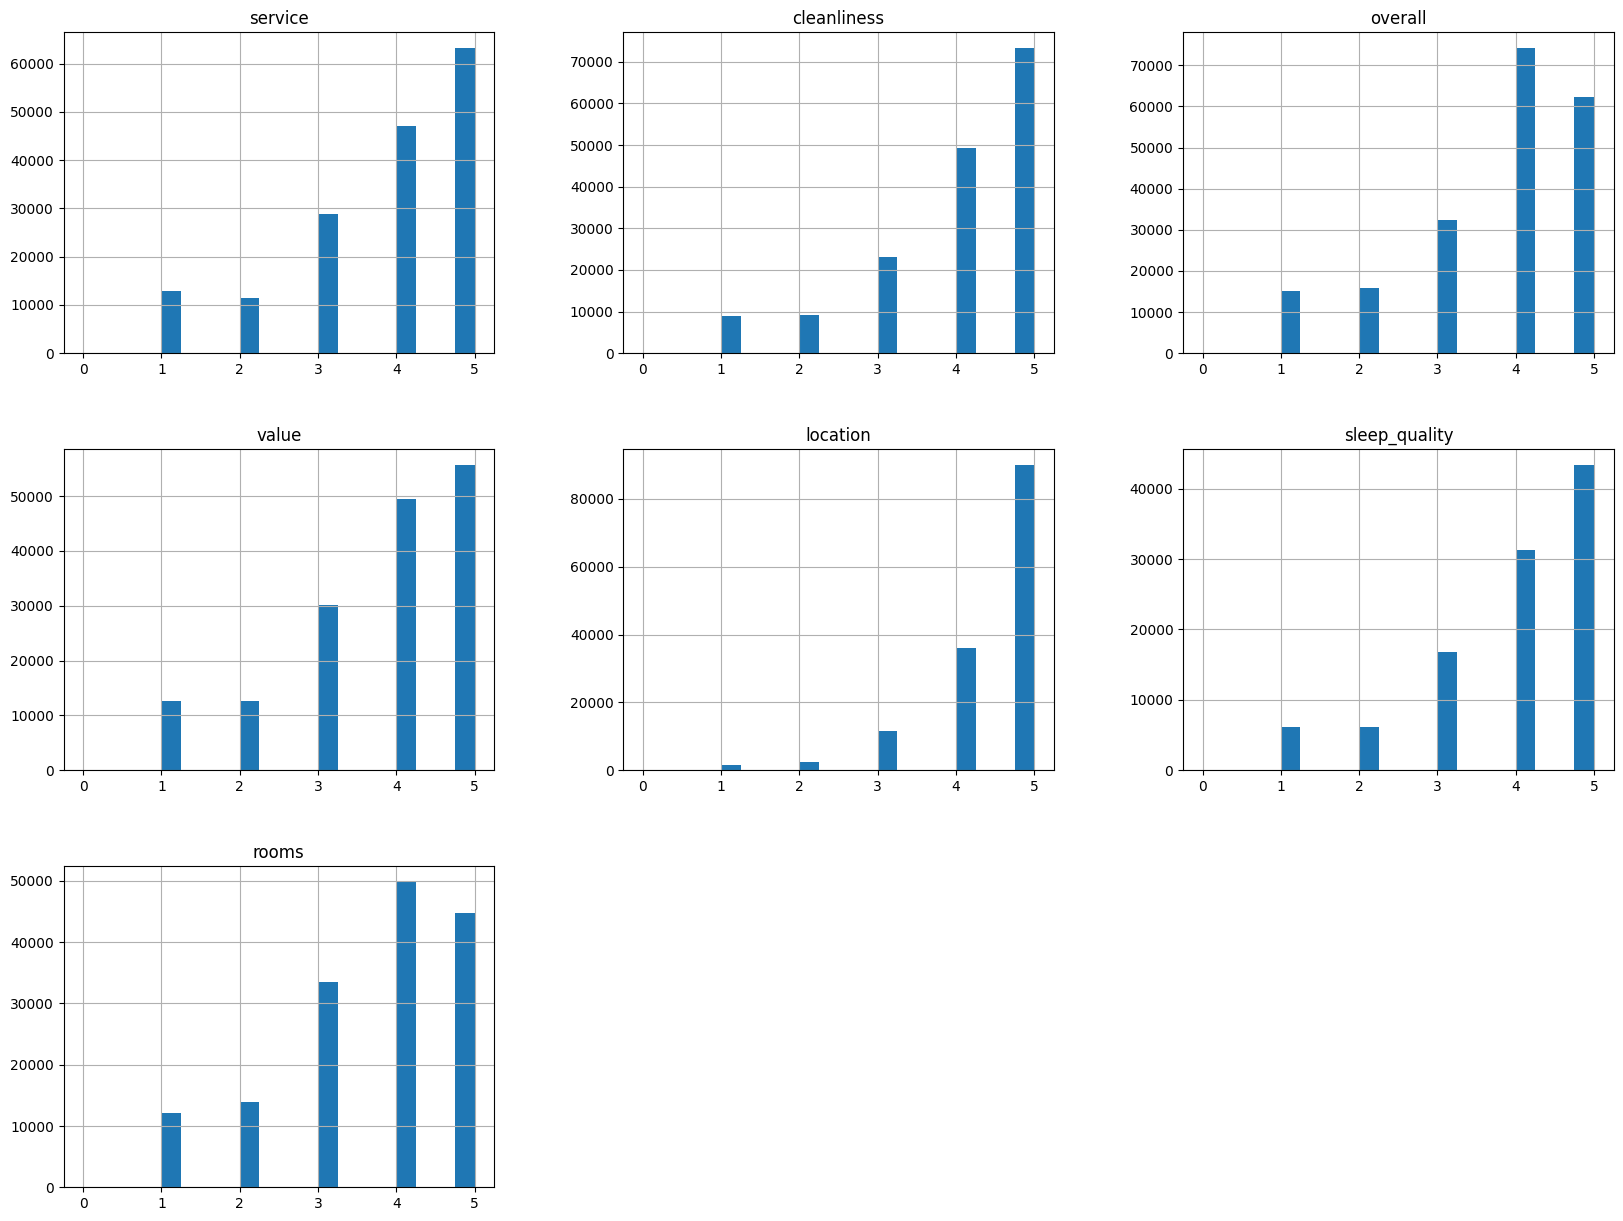

In [18]:
# The medians (50%) look high on a scale of 1-5 (median of 4 or 5).

# Plot histograms to show the distribution of the reviews.

df.loc[:, 'service':'rooms'].hist(bins=20, range=[0, 5], figsize=(20,15))
plt.show()


Now add a new column to classify the review into a general sentiment as either _positive_ or _negative_ using weak supervision.  Weak supervision is non-manual classification that uses a heuristic.  The heuristic in this case is that only overall ratings of 4 or 5 are going to be classified as _positive_.

In [19]:
# The data skews right (high) on the ratings.  This is standard in reviews where
# sometimes it's '5 stars or nothing'.

# Add a new column and set anything lower than a 4 (out of 5) on the "overall" rating column
# as a negative review.  This is due to the data skewing right.

# The "overall" rating column will be used as it is complete.

# We can change this to be poor, satisfactory, good, excellent; however, a binary classification,
# positive / negative, may work best.

# We can also, instead of just using the 'overall' rating, combine all the ratings with a weighting.
# But that can be future work!

df['sentiment'] = np.where(df['overall'] >= 4, 'positive', 'negative')

In [20]:
# Take a look to see what the positive / negative review breakdown looks like.  We want to make sure it's
# not an imbalanced data.
#
# Positive = 136,651 / 199,998 = 68%
# Negative =  63,347 / 199,998 = 32%
#
# Perfect!  A 70-30 split is usually

df['sentiment'].value_counts()

,count
sentiment,
positive,136651
negative,63347


## <font color="Blue">Sentiment Analysis</font>


Sentiment Analysis is part of Natural Language Processing (NLP) where text is analyzed to determine its underlying emotion.  Sentiment can be _happy_, _sad_, _confused_ etc. but in this project, the sentiment will just be binary: _positive_ or _negative_.

Sentence BERT will be used for the semantic similarity matching as it matches meaning based on the entire sentence, not exact keywords or derivatives of those keywords.

Sentiment analysis can be used in customer review use cases such as:

#### Use Case #1: Sentiment Analysis of a Customer Review

From a hotel owner's point of view, classify a customer's review as either positive or negative.

A hotel owner could use this information to determine if they should reach out to the customer.

#### Use Case #2: Searching / Retrieving Hotel Reviews Based on Sentiment

From a customer's point of view, enter a search query, <i>"What hotels have friendly staff"</i>.  Semantic text match based on the query and set of reviews to get the top similarity matches.  Combine with deep learning for the sentiment.



###<font color="Blue">Text Encoding Using Sentence BERT</font>


####<font color="Blue">Define Sentence BERT Model</font>

In [21]:
# Import libraries required for sentence BERT.

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

# Create the BERT model.

_model = SentenceTransformer("all-MiniLM-L6-v2")


# bulk_encode_phrases

def bulk_encode_phrases(src_col, dest_col):

    try:

        # For all reviews in the dataset, encode them into
        # their numeric values.

        embeddings = _model.encode(
            df['text'].tolist(),
            batch_size=64,         # Process 64 phrases at a time
            show_progress_bar=True)

        # Create the text_embedding column in the dataframe
        # based one the encoding.

        df['text_embedding'] = list(embeddings)

    except Exception as ex:

      print("Exception:", ex)


# encode_phrase

def encode_phrase_using_bert(phrase):

    try:

        # Encode the phrase.

        phrase_embedding = _model.encode([phrase])

        # Return the embedded phrase.

        return phrase_embedding[0]

    except Exception as ex:

      print("Exception:", ex)


# find_similar_bert_matches

def find_similar_bert_matches(query_term, documents):

    try:

        # Encode the documents and query.

        documents_embeddings = _model.encode(
            documents,
            batch_size=64,
            show_progress_bar=True
        )

        query_embedding = _model.encode([query_term])

        # Calculate the similarities.

        similarities = cosine_similarity(query_embedding, documents_embeddings)[0]

        # Sort the similarity indices.

        similarity_indices = np.argsort(similarities)[::-1]

        # Return all the matches by index.

        return similarity_indices, similarities

    except Exception as ex:

        print("Exception:", ex)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

####<font color="Blue">Test Sentence BERT Model</font>

In [22]:
# test_bert_similarity_matches

def test_bert_similarity_matches(query_term, num_of_reviews_to_search):

    try:

        # Get a random set of reviews so they are not taken from the first 1000 in the dataset, for example.

        random_reviews = df['text'].sample(n=num_of_reviews_to_search, random_state=42).tolist()

        # "Hotels that are clean" will match negative as well as positive
        # Put query through positive / negative first (i.e., don't rely on the overall indicator)

        # Other queries: "Hotels where the staff are friendly"

        similarity_indices, similarities = find_similar_bert_matches("Hotels that are clean", random_reviews)

        # Print out the top 5.

        print("\n\nTop 5 Documents by Similarity:")
        print("------------------------------\n\n")

        for id in similarity_indices[0:5]:
              print("Document", id, "(", similarities[id], ")")
              print(random_reviews[id], "\n\n")

        # Return the results.

        return similarity_indices, similarities

    except Exception as ex:

        print("Exception:", ex)



In [23]:
# Performance Test Notes

# Using a CPU runtime, searching 200K reviews will take a very long time as 1K reviews can take 1 minute (CPU)
# and 10K reviews takes 12 minutes (CPU).
# However, using a GPU runtime, searching 10K reviews only takes 30 s.

# Test that a query will retrieve matches that are similar.
# At this point, the text review searches is strictly on the text, independent of sentiment or other features such as City.

# Define the number of reviews to randomly search.

num_of_reviews_to_search = 1000
test_query = "Hotels that have friendly staff"

similarity_indices, similarities = test_bert_similarity_matches(test_query, num_of_reviews_to_search)


Batches:   0%|          | 0/16 [00:00<?, ?it/s]



Top 5 Documents by Similarity:
------------------------------


Document 705 ( 0.68755966 )
This hotel has a great locaton, however, the room was not clean! The bathroom light fixtures were broken, and the hair dryer did not work. We needed to call to the front desk twice for a replacement since we were trying to make it to a Broadway show. Front desk staff and bell staff were very rude! Not impressed and way too expensive! 


Document 652 ( 0.6753286 )
I stayed last summer, and this hotel was great! Shared bathrooms were always clean, rooms were quiet, and the stay was nice. If you are looking for somewhere budget friendly to stay, that is clean and centrally located, then this one is perfect! Definitely would stay again! 


Document 774 ( 0.6684314 )
This hotel is very conviently located, but isn't very clean and the rooms are mediocore. Valet takes 20 mins or so, and there's no wow factor for this hotel. Very average, or a bit below. The bathrooms are very small with some signs of

In [24]:
# Get a general sense of similarity score matches in the query results.

similarities

array([ 0.44851676,  0.62152076,  0.18798456,  0.5117456 ,  0.3808895 ,
        0.45790207,  0.5163707 ,  0.41540393,  0.54840046,  0.38633204,
        0.3311282 ,  0.48296648,  0.5319181 ,  0.3092973 ,  0.4085277 ,
        0.49786207,  0.35504702,  0.42622343,  0.5559093 ,  0.20981464,
        0.49683914,  0.3952194 ,  0.4413775 ,  0.5322078 ,  0.40896422,
        0.28353912,  0.4632904 ,  0.48998225,  0.41092363,  0.44794852,
        0.50942993,  0.44377607,  0.35891262,  0.45880932,  0.26037407,
        0.51015204,  0.4560029 ,  0.50167423,  0.5200264 ,  0.445508  ,
        0.40803647,  0.45353895,  0.48775825,  0.09615672,  0.39142624,
        0.40522236,  0.30919808,  0.52255034,  0.50986874,  0.4264658 ,
        0.42341736,  0.30432278,  0.3406875 ,  0.22584705,  0.2254487 ,
        0.4980553 ,  0.49740878,  0.50513   ,  0.57935613,  0.56206954,
        0.32472426,  0.3376519 ,  0.32078648,  0.38418788,  0.22671333,
        0.42346936,  0.45775786,  0.49527973,  0.16560405,  0.42

## <font color="Blue">Deep Learning Predictive Analytics</font>

Adding a Deep Learning Model can assist in associating user reviews with an overall sentiment instead of just a plain semantic search.  This has the following benefits:

- Knowing if a user review is positive or negative can help hoteliers identify unsatisfied customers.

- During search performance, users searching for hotels based on a particular query can filter out non-related data (e.g., if you are looking for something positive, filter out the negative reviews as these could just be noise)

- Training a Deep Learning Model using additional features, such as City, can help fine-tune the sentiment of a review based on other factors.

The Deep Learning Model will be a classification model based on the _target_ sentiment (positive, negative).

The _features_ in the Deep Learning Model will be the encoded text review as well as the hotel's city.  Future work can add more features such as amenities (e.g., does having an indoor pool increase the likelihood of a positive review independent of the textual review).

The assumption in the weak supervision that was already done was that a person would write a review that would match their overall score.  In other words, they are not going to write a terrible review and give it a 5 / 5 rating.

Therefore, the goal is to train the deep learning model to associate text reviews and the hotel's city to either a positive or negative review.



### <font color="Blue">Deep Learning Model</font>


Define the features that will be used in the Deep Learning Neural Network.

The features will be:
- Encoded hotel review text
- Other hotel review records features such as city

The text review will first be encoded using Sentence BERT text and those text embeddings will be stored in a new column.

The new column, text_embedding, along with the city will be used as the features to predict sentiment.

A weak supervision was used to provide a weak supervision-based classification of a review's sentiment based on an overall rating.  Now a deep learning model will be trained on this review and the city against this sentiment to see if searching based on reviews and other features (i.e., just city for now) has an impact on the search results.

The top search results will be passed back to the user.


####<font color="Blue">Encode Text Reviews</font>

In [25]:
# Create a new column in the dataframe to convert the review text
# to the encoded sentence using the BERT embedding.

# Warning: this can take a long time if not being processed with a GPU
# as it is encoding every text review in the dataset.

bulk_encode_phrases('text', 'text_embedding')

Batches:   0%|          | 0/3125 [00:00<?, ?it/s]

In [26]:
# Take a look at the columns to make sure the text_embedding column is there.

df.columns

Index(['hotel_class', 'region_id', 'url', 'type', 'id_x', 'name', 'region',
       'street-address', 'postal-code', 'locality', 'full_address', 'latitude',
       'longitude', 'title', 'text', 'author', 'date_stayed', 'offering_id',
       'num_helpful_votes', 'date_reviewed', 'id_y', 'via_mobile', 'service',
       'cleanliness', 'overall', 'value', 'location', 'sleep_quality', 'rooms',
       'sentiment', 'text_embedding'],
      dtype='object')

In [27]:
# Take a look at the feature (encoded text) and the target (sentiment)
# as this is what the Deep Learning model will be training on.

df[['text_embedding', 'sentiment']].head()

,text_embedding,sentiment
0,"[-0.021180902, -0.007858698, 0.020347165, -0.0...",positive
1,"[0.057014972, 0.054681372, 0.039441764, 0.0978...",positive
2,"[0.052122597, -0.033031747, 0.036357775, 0.061...",positive
3,"[0.111799635, -0.034462586, 0.06117618, 0.0227...",positive
4,"[0.08409205, -0.051840566, 0.06453733, 0.08206...",positive


####<font color="Blue">Define Deep Learning Model</font>

In [28]:
# Import libraries.

import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping


# Prepare the feature (text_embedding) and the target.

le = LabelEncoder()

# Build the features.
# Feature: text_embedding (encoded integer values of the text review)
#          city

X_review = np.vstack(df['text_embedding'].values)
city_encoded = pd.get_dummies(df['locality'], prefix='locality')
city_columns = city_encoded.columns

X = np.hstack([X_review, city_encoded.values])

# Set the target.
# Target:  sentiment ('positive' or 'negative' based on the 'overall' rating)

y = le.fit_transform(df['sentiment'])

# Split the training and test data based on a 80-20% split.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Build deep learning classification model.

dl_model = keras.Sequential([
    layers.Input(shape=(X.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Sigmoid output layer for classification
])

# Compile model.

dl_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the deep learning model.

# Add early stopping once validation data loss has plateaued.
# This stops overfitting.

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True)

# Train the model.  Note that due to early stopping, the number of
# epochs doesn't get past 9.  This is supposedly quite good. :-)

dl_training_history = dl_model.fit(X_train,
                                   y_train,
                                   epochs=20,       #  10 - see early stopping note
                                   batch_size=32,   #  64
                                   validation_split=0.2,
                                   callbacks=[early_stopping])



Epoch 1/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.8038 - loss: 0.4237 - val_accuracy: 0.8201 - val_loss: 0.3959
Epoch 2/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8183 - loss: 0.3986 - val_accuracy: 0.8240 - val_loss: 0.3896
Epoch 3/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8223 - loss: 0.3908 - val_accuracy: 0.8251 - val_loss: 0.3859
Epoch 4/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8242 - loss: 0.3865 - val_accuracy: 0.8266 - val_loss: 0.3834
Epoch 5/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8272 - loss: 0.3819 - val_accuracy: 0.8262 - val_loss: 0.3832
Epoch 6/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8297 - loss: 0.3781 - val_accuracy: 0.8278 - val_loss: 0.3813
Epoch 7/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8313 - loss: 0.3754 - val_accuracy: 0.8257 - val_loss: 0.3841
Epoch 8/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8337 - loss: 0

####<font color="Blue">Deep Learning Model Training and Validation Results</font>

In [29]:
# Import libraries

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Calculate the loss and accuracy of the model:

test_loss, test_accuracy = dl_model.evaluate(X_test, y_test)
print(f"Test data accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")

# Generate the predictions to see how well it matches up.

predictions = dl_model.predict(X_test)
prediction_labels = (predictions > 0.5).astype(int)

# Iterate over the first 10 predictions.

for i in range(10):

    prediction = "positive" if prediction_labels[i] == 1 else "negative"
    actual     = "positive" if y_test[i] == 1 else "negative"

    print("Prediction vs Actual:", prediction, "->", actual)

# Print the confusion matrix.

cm = confusion_matrix(y_test, prediction_labels)
print("Confusion Matrix")
print("----------------")
print(cm)

# Finally, print the classification report.

print("Classification Report")
print("---------------------")
print(classification_report(y_test, prediction_labels))

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8270 - loss: 0.3775
Test data accuracy: 0.8270
Test loss: 0.3775
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Prediction vs Actual: positive -> positive
Prediction vs Actual: positive -> positive
Prediction vs Actual: negative -> negative
Prediction vs Actual: negative -> positive
Prediction vs Actual: positive -> positive
Prediction vs Actual: positive -> positive
Prediction vs Actual: negative -> negative
Prediction vs Actual: positive -> positive
Prediction vs Actual: positive -> negative
Prediction vs Actual: positive -> positive
Confusion Matrix
----------------
[[ 7870  4800]
 [ 2120 25210]]
Classification Report
---------------------
              precision    recall  f1-score   support

           0       0.79      0.62      0.69     12670
           1       0.84      0.92      0.88     27330

    accuracy                           0.83     40000
   macro avg       0.81      0.77      0.79     40000
weighted avg       0.82 

Now visualize the training data accuracy and loss over the training history (epochs).  

In [30]:
# plot_loss

def plot_loss(training_history):

    # Plot the Loss values for the model training (over the epochs).

    plt.plot(training_history.history['loss'], label='Loss - Training Data')
    plt.plot(training_history.history['val_loss'], label='Loss - Validation Data')
    plt.legend()
    plt.show()


# plot_accuracy

def plot_accuracy(training_history):

    # Plot the Accuracy values for the model training (over the epochs).

    plt.plot(training_history.history['accuracy'], label='Accuracy - Training Data')
    plt.plot(training_history.history['val_accuracy'], label='Accuracy - Validation Data')
    plt.legend()
    plt.show()


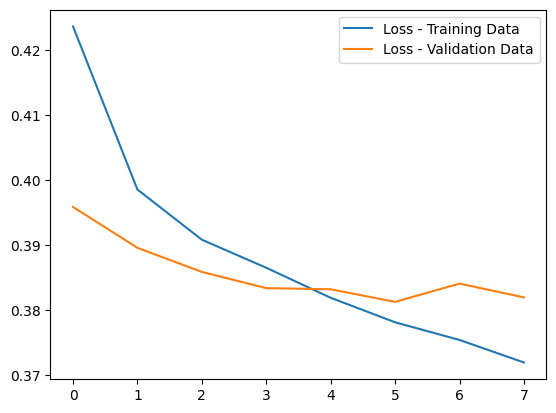

In [31]:
# Plot the loss graph.

plot_loss(dl_training_history)


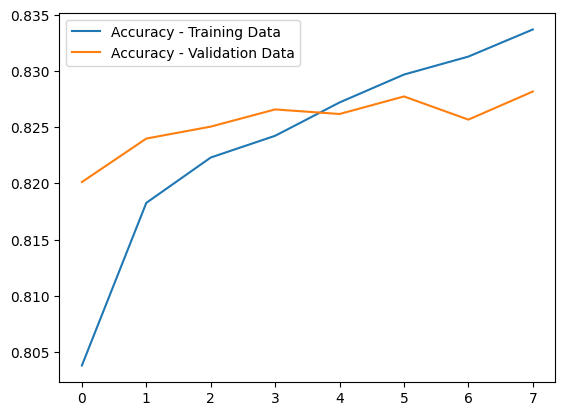

In [32]:
# Plot the accuracy graph.

plot_accuracy(dl_training_history)


####<font color="Blue">Training Results Summary</font>

The above graphs show that the accuracy is increasing over time until about 7 or 8 epochs and the loss in the training data is decreasing.  Even though 20 epochs were specified, an early stopping mechanism was added to stop once the validation data loss had plateaued.  This stops overfitting of the data.  The validation data performance stopped improving around epoch 7 - 9.

The overall accuracy is approximately 83% which is quite good.

Based on the recall numbers from the confusion matrix / classification report, it looks like _positive_ reviews are identified well (92%) but we may be missing 38% of the _negative_ reviews.  Therefore, as part of future parameter tuning, we may have to adjust our weak classification heuristic to create a more balanced dataset of positives and negatives (right now, ~70/30 split) or change our positive prediction from > .5 to a prediction > .6.

####<font color="Blue">Test Deep Learning Model</font>

Now test the deep learning model using test review data.

In [33]:
# predict_sentiment

def predict_sentiment2(text, city, dl_model, embedder_model):

    try:

        # Encode the text using the same text embedding model used when
        # encoding the reviews feature training set.

        emb = embedder_model.encode([text]).astype('float32')
        city_vec = pd.get_dummies(pd.Series([city]), prefix='locality')
        city_vec = city_vec.reindex(columns=city_columns, fill_value=0)

        X_new = np.hstack([emb, city_vec.values])

        # Create the prediction using the deep learning classification model.

        #pred = dl_model.predict(emb)[0][0]
        prediction = dl_model.predict(X_new)

        # Return the prediction result.

        return "Positive" if prediction > 0.5 else "Negative"

    except Exception as ex:

        print("Exception:", ex)


# predict_sentiment

def predict_sentiment(text, city, dl_model, embedder_model):

    try:

        # Encode the text review.

        emb = embedder_model.encode([text]).astype('float32')

        # Encode the city.

        city_vec = pd.get_dummies(pd.Series([city]), prefix='locality')
        city_vec = city_vec.reindex(columns=city_columns, fill_value=0)
        city_array = city_vec.values.astype('float32')

        # Combine the featuress.

        X_new = np.hstack([emb, city_array]).astype('float32')

        # Make the prediction.

        prediction = dl_model.predict(X_new)[0][0]

        return "Positive" if prediction > 0.5 else "Negative"

    except Exception as ex:

        print("Exception:", ex)



In [34]:
# Test reviews

reviews = ["I thought the service was ok but the meals were excellent!",
           "The location was good.",
           "The staff was friendly and helpful.",
           "We checked in late at night and the service was terrible.",
           "location good, service ok and staff were so-so.",
           "The cleanliness of the rooms could be better.",
           "The hotel was cleaned from top to bottom."]

# Iterate over the test reviews.

for review in reviews:

    # Encode the review using the same BERT model as the features were encoded.

    embedding = _model.encode([review])

    # Predict if the hotel review is positive or negative.

    print(review, ":", predict_sentiment(review, "Houston", dl_model, _model))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
I thought the service was ok but the meals were excellent! : Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
The location was good. : Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
The staff was friendly and helpful. : Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
We checked in late at night and the service was terrible. : Negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
location good, service ok and staff were so-so. : Positive
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
The cleanliness of the rooms could be better. : Negative
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
The hotel was cleaned from top to bottom. : Negative


The above results will indicate how well the model was trained to recognize positive and negative reviews.  Note that based on how reviews are worded, a positive review may be interpreted as a negative.  However, that's AI!  And that can be part of future work.

In [35]:
# Trying different layers/models to compare performance

# Base model
def reviews_model1(input_dim):
    model1 = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model1.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model1

# Adding more layers
def reviews_model2(input_dim):
    model2 = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model2.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model2

# Dropout and Batch normalization
def reviews_model3(input_dim):
    model3 = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])

    model3.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model3

# Different Optimizer
def reviews_model4(input_dim):
    model4 = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model4.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model4

In [36]:
# Fit the different model types
review_models = {
    "Model1_Baseline": reviews_model1(X.shape[1]),
    "Model2_Layers": reviews_model2(X.shape[1]),
    "Model3_Drop_Batch": reviews_model3(X.shape[1]),
    "Model4_Opt_RMSprop": reviews_model4(X.shape[1])
}

histories = {}

for name, model in review_models.items():
    print(f"\nTraining {name}:\n")

    history = model.fit(
        X_train, y_train, # X, y,
        epochs=20,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1
    )

    histories[name] = history


Training Model1_Baseline:

Epoch 1/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.8040 - loss: 0.4228 - val_accuracy: 0.8195 - val_loss: 0.3956
Epoch 2/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8185 - loss: 0.3981 - val_accuracy: 0.8240 - val_loss: 0.3893

Training Model2_Layers:

Epoch 1/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.8091 - loss: 0.4123 - val_accuracy: 0.8223 - val_loss: 0.3903
Epoch 2/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.8230 - loss: 0.3880 - val_accuracy: 0.8256 - val_loss: 0.3875

Training Model3_Drop_Batch:

Epoch 1/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.7934 - loss: 0.4428 - val_accuracy: 0.8106 - val_loss: 0.4117
Epoch 2/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.8074 - loss: 0.4172 - val_accuracy: 0.8163 - val_loss: 0.3995

Training Model4_Opt_RMSprop:

Epoch 1/20
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8071 - loss: 0.4157 - val_accu

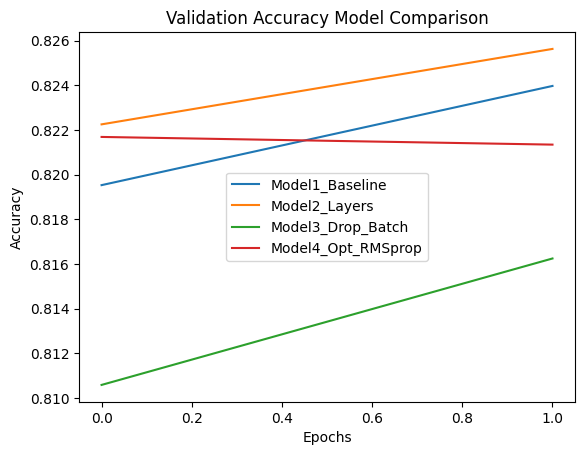

In [37]:
# Plotting the accuracies of each model type
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)

plt.title("Validation Accuracy Model Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

The baseline model used for this project shows a steady learning capacity increase over time at the highest average accuracy. This is a stable model that shows consistent performance.

The model incorporating more layers had the highest accuracy increase showing its increased learning capability over time. If not trained for longer, this model would underfit.

The model with Dropout and Batch Normalization had the lowest average accuracy over time showing its stability but at lower performance.

The model incorporating optimization RMSprop also had accuracy increase over time however, not as much of a learning capacity change compared to the layered model.

All the models had minute differences in score (range between 0.814-0.826) overall. This shows that the embeddings for this model (baseline) are already very strong.

##<font color="Blue">Sentiment Query Pipeline</font>

####<font color="Blue">Define the Sentiment Query Pipeline</font>

In [38]:
# find_hotels

def find_hotels(hotel_query, num_of_reviews_to_search, city="New York City"):

    try:

        # Predict if the hotel query is positive or negative.

        embedding = _model.encode([hotel_query])
        sentiment_prediction = predict_sentiment(hotel_query, city, dl_model, _model)

        # Add a debug flag.

        print(hotel_query, ":", sentiment_prediction)
        print(f"'{sentiment_prediction}'")

        # Get a random set of reviews so they are not taken from the first 1000 in the dataset, for example.
        # Only search the reviews that match the sentiment.  Therefore, if the hotel query is positive
        # search only the positive reviews.

        random_reviews = df.loc[(df['sentiment'] == sentiment_prediction.lower()) &
                                (df['locality'] == city), 'text'] \
            .sample(n=num_of_reviews_to_search, random_state=42) \
            .tolist()

        # Find similar matches between the hotel query and the set of random reviews.

        similarity_indices, similarities = find_similar_bert_matches(hotel_query, random_reviews)

        review_matches = []

        # Iterate over the top 10 reviews to create the dataset.

        for id in similarity_indices[0:10]:

            # Get the index of the record that matches the review.

            new_index = df[df['text'] == random_reviews[id]].index[0]

            # Set a pointer to the record.

            row = df.iloc[new_index]

            # Get the data from this record.

            review_details = {
                "index": new_index,
                "similarity": similarities[id],
                "hotel": row['name'],
                "address": row['full_address'],
                "locality": row["locality"],
                "postal-code": row["postal-code"],
                "review": row["text"],
                "longitude": row["longitude"],
                "latitude": row["latitude"]
            }

            # Add the review record to the list.

            review_matches.append(review_details)

        # Return the matches.

        return review_matches

    except Exception as ex:

        print("Exception:", ex)


####<font color="Blue">Test Sentiment Query Pipeline</font>

In [39]:
# Test the output so we can see what we can include in results.

hotel_queries = ["Hotels that are well cleaned", "Hotels where the staff are friendly",
                 "Hotels that have a good food", "Hotels that are terrible"]

# Iterate over the test hotel queries.

for hotel_query in hotel_queries:

    matches = find_hotels(hotel_query, 100, "Houston")

    print("Query: ", hotel_query)
    print("------------------------------------------\n")

    for match in matches:
        print ("Match:", match["similarity"])
        print ("Hotel:", match["hotel"])
        print ("Address:", match["address"])
        print (match["review"], "\n")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Hotels that are well cleaned : Negative
'Negative'


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Query:  Hotels that are well cleaned
------------------------------------------

Match: 0.62946945
Hotel: Houston Marriott West Loop by the Galleria
Address: 1750 West Loop South, Houston, TX, 77027, USA
I stayed at this hotel this past weekend along with 2 of my kids. The room was clean with nice decor. I found the headboard of the beds to be somewhat outdated with an attached reading light. The staff we came in contact with were warm and receiving, offering a smile and their thanks for staying with them. I didn't dine in the restaurant, it had the appearance of a sport's bar so we decided to so eat someplace in the surrounding area. This hotel is in a great area for shopping and dining, plus it has easy access to the freeway. My kids were at the pool for a short time. They complained of the water being too cold. The hotel had a nice supply of towels at poolside and the area was clean until a group of teenagers sprayed silly string all over. I had a nice experience here and would retu

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Query:  Hotels where the staff are friendly
------------------------------------------

Match: 0.67632174
Hotel: Residence Inn Houston Northwest/Willowbrook
Address: 7311 West Greens Road, Houston, TX, 77064, USA
I recently stayed at this hotel for five nights on business, and was extremely impressed with the staff and overall quality, given the bargain price. The suite was extremely spacious and clean. I have stayed at many luxury-level hotels with rooms that were not nearly as comfortable and well-appointed. The staff went out of their way to be helpful. The locale is not ideal -- on the freeway, my room overlooking a wind-blown lot and water tower; the only walkable restaurant is a Japanese place. But it is across the street from the Willowbrook Mall, with endless chain-dining options all around. It is a good base for business travelers, and I would return. 

Match: 0.67161626
Hotel: Park Inn by Radisson, Houston North
Address: 500 N Sam Houston Pkwy, Houston, TX, 77060, USA
We stay

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Query:  Hotels that have a good food
------------------------------------------

Match: 0.6648258
Hotel: Hyatt Place Houston/Greenspoint/IAH Airport
Address: 300 Ronan Park Place, Houston, TX, 77060, USA
Very nice hotel with good facility and very helpful staff. The room is of good size and endowed with good facility inside. Big TV, good bathroom cosmetics, bed, sofa and all other things are good. Breakfast is also good. Pools are also good. Parking area is big. Internet and printout facility is also good(when internet printer was not working reception helped me to get print out from the invoice printer). Lobby area is little small, but it is clean. Hotel is little away from airport, but all other good things can easily outweigh this. 

Match: 0.6489888
Hotel: Hampton Inn Houston - I-10W, Energy Cor
Address: 11333 Katy Freeway, Houston, TX, 77079, USA
We like this hotel because the room is clean and the staff is friendly. The complimentary breakfast is delicious. This hotel is well man

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Query:  Hotels that are terrible
------------------------------------------

Match: 0.7738434
Hotel: Howard Johnson Houston
Address: 2221 Greens Road, Houston, TX, 77032, USA
This was nearly the worst hotel I have ever stayed. My room was old, not clean, lighting miscommunications, and location with not transportation mid-day a nightmare! I will never recommend this hotel. 

Match: 0.6538503
Hotel: DoubleTree Suites by Hilton Houston by the Galleria
Address: 5353 Westheimer Road, Houston, TX, 77056-5474, USA
I found this hotel to be be average. The rooms are huge, but the water pressure was bad in the shower. Room service was bad as well. I received hash browns with my hamburger instead of french fries. The biggest upset was that I think they may have bedbugs. I was bitten all down the leg and arm of the side I was sleeping on. I will not be going back. 

Match: 0.5811469
Hotel: La Quinta Inn Houston Wilcrest
Address: 11113 Katy Freeway, Houston, TX, 77079-2102, USA
I booked this Hotel

The results above are better than the results earlier where semantic searching was tested by itself, independent of city and sentiment.  The query _Hotels that have friendly staff_ was returning some results that were not correct.  

However, the same query above where a deep learning model was used to predict sentiment in the query and then the results filtered based on that sentiment and city gave better results.

### <font color="Blue">Performance Optimizations</font>



In [40]:
# As part of performance optimizations, the modified data frame (from data cleaning, text embedding and sentiment
# target creation) can be outputted to a file.
#
# However, this takes a very long time just for one file so we don't need to do this but we can make
# note of it in the presentation as a future work item.

# Store the dataframe to a CSV file so that the embeddings don't need to be created again.

#df.to_csv(file_path + "/reviews1_with_text_embedding.csv")

## <font color="Blue">Application: User Interfaces</font>

Here are three examples of user applications that could be used as a layer over the deep learning and BERT encoding data models.  It uses Gradio to provide these proof-of-concept UIs.

- **Use Case 1: Hotel Review Sentiment Prediction** Enter a user review text and a city to predict if the review is positive or negative for that city.

- **Use Case 2: Hotel Review Sentiment Query Report** Enter a user review text and a city to get a list of all hotels that match based on similarity.

- **Use Case 3: Hotel Review Sentiment Search Map** Enter a user review text and a city and plot the results on a map.


####<font color="Blue">Code Wrappers</font>

In [41]:
#!pip install gradio
#!pip install --upgrade gradio

In [42]:
# Import libraries.

import gradio as gr
import plotly.graph_objects as go


In [43]:
# Wrap the prediction method.

def predict_review_sentiment(review_text, city):

    try:

        # Return the prediction.

        return predict_sentiment(review_text, city, dl_model, _model)

    except Exception as ex:

        print("Exception:", ex)

In [44]:
# Wrap the search method.

def find_hotels_based_on_query(review_text, city):

    try:

        # Find the hotels with the best match from n randomly-selected reviews.

        hotel_matches = find_hotels(review_text, 1000, city)

        # Extract the hotels.

        hotels = [(item["hotel"], item["address"], item["review"], item["longitude"], item["latitude"]) for item in hotel_matches]

        hotel_reviews = pd.DataFrame(hotels, columns=["hotel", "address", "review", "longitude", "latitude"])

        # Return the hotel matches.

        return hotel_reviews

    except Exception as ex:

        print("Exception:", ex)

In [45]:
test_matches = find_hotels_based_on_query("Hotels that are friendly", "Houston")
test_matches

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Hotels that are friendly : Positive
'Positive'


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

,hotel,address,review,longitude,latitude
0,Residence Inn by Marritt Houston Downtown /Con...,"904 Dallas Street, Houston, TX, 77002, USA",The hotel is nice. Staff was very friendly and...,-95.366634,29.755562
1,Four Points by Sheraton Houston Hobby Airport,"8720 Gulf Freeway, Houston, TX, 77017, USA","Looking for a nice hotel, that has all the ame...",-95.260246,29.664137
2,HYATT house Houston/Galleria,"3440 Sage Rd, Houston, TX, 77056, USA",This hotel is great. Room is clean and staff i...,-95.467903,29.729252
3,Comfort Inn Hwy. 290/NW,"7887 West Tidwell Road, Houston, TX, 77040, USA",A very nice hotel. Close to lots of restaurant...,-95.510616,29.850121
4,Houston Marriott West Loop by the Galleria,"1750 West Loop South, Houston, TX, 77027, USA",I've been at this hotel for 4 weeks now as I w...,-95.456106,29.749711
5,Hyatt Place Houston/Greenspoint/IAH Airport,"300 Ronan Park Place, Houston, TX, 77060, USA",Very nice hotel with good facility and very he...,-95.400510,29.942058
6,La Quinta Inn Houston Greenway Plaza,"4015 Southwest Freeway, Houston, TX, 77027-749...",This is a nice pleasant hotel close to everyth...,-95.443197,29.729443
7,Americas Best Value Inn & Suites - Houston/Nor...,"12170 Northwest Freeway, Houston, TX, 77092, USA","If you re expecting luxury, continental breakf...",-95.483064,29.834110
8,Sheraton North Houston at George Bush Intercon...,"15700 John F Kennedy Boulevard, Houston, TX, 7...",I had to stay there overnight because I missed...,-95.331238,29.945561
9,Westin Galleria Houston Hotel,"5060 West Alabama Street, Houston, TX, 77056, USA",I traveled with friends on short notice and ma...,-95.464496,29.738339


####<font color="Blue">Use Case 1: Hotel Review Sentiment Prediction</font>

In [46]:
import gradio as gr

# Gradio interface for classifying a review as positive or negative.

gr.Interface(
    fn=predict_review_sentiment,
    inputs=[
        gr.Textbox(lines=2, label="Review Text", placeholder="Enter review text here..."),
        gr.Dropdown(choices=["New York City", "Houston"], label="Select a city")
    ],
    outputs=gr.Textbox(lines=1, label="Sentiment"),
    title="Hotel Review Sentiment Prediction",
    description="A sentiment prediction application to determine if a user's hotel review is positive or negative."
).launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4f550ba4999e542fae.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


####<font color="Blue">Use Case 2: Hotel Review Sentiment Query Report</font>




In [47]:
# Gradio interface for finding the best sentiment matches for a query and the
# hotel's city.

gr.Interface(
    fn=find_hotels_based_on_query,
    inputs=[
        gr.Textbox(lines=2, label="Review Text", placeholder="Enter review text here..."),
        gr.Dropdown(choices=["New York City", "Houston"], label="Select a city")
    ],
    outputs=gr.Dataframe(label="Hotels"),
    title="Hotel Review Sentiment Query Report",
    description="A sentiment query to provide a iist of hotels based on similarity matches."
).launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c957d16b40b0f0d70a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


####<font color="Blue">Use Case 3: Hotel Review Sentiment Search Map</font>


In [48]:
# wrap_text

def wrap_text(text, width=60):
    return "<br>".join([text[i:i+width] for i in range(0, len(text), width)])


# filter_query

def filter_map(query, city):

    # Get a list of hotels based on the user's query.

    hotel_reviews = find_hotels_based_on_query(query, city)

    hotel_reviews['wrapped_review'] = hotel_reviews['review'].apply(lambda x: wrap_text(str(x), 60))

    # Plot these hotel matches on a map.

    fig = go.Figure(go.Scattermapbox(
        customdata=hotel_reviews[['hotel', 'address', 'wrapped_review']].fillna('').values,
        lat=hotel_reviews['latitude'],
        lon=hotel_reviews['longitude'],
        mode='markers',
        marker=go.scattermapbox.Marker(size=12),
        hovertemplate=(
            "<b>Name</b>: %{customdata[0]}<br>" +
            "<b>Address</b>: %{customdata[1]}<br>" +
            "<b>Review</b>: %{customdata[2]}<br>" +
            "<extra></extra>"
        )
    ))


    # Define the map details.

    fig.update_layout(
        mapbox_style="open-street-map",
        hovermode='closest',
        mapbox=dict(
            bearing=0,
            center=dict(lat=hotel_reviews.iloc[0]['latitude'], lon=hotel_reviews.iloc[0]['longitude']),
            pitch=0,
            zoom=12
        ),
    )

    return fig

# Create the user input block.

with gr.Blocks() as demo:
    with gr.Column():
        query = gr.Textbox(
            lines=2,
            label="Hotel Search",
            placeholder="Enter review text here..."
        )

        city = gr.Dropdown(
            choices=["New York City", "Houston"],
            label="Select a city"
        )

        btn = gr.Button(value="Find Hotels")
        map = gr.Plot()

    demo.load(filter_map, [query, city], map)
    btn.click(filter_map, [query, city], map)

demo.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6cccc2607f541f6ee1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## <font color="Blue">Future Work</font>

Sentiment searching as part of Natural Language Processing provides many opportunities to assist users in finding the information for which they are looking.

Further work can be done in the areas of:

- Fine-tune deep learning model to increase accuracy
- Fine-tune semantic sentence encoding to account for subtleties in language
- Performance optimizations to accommodate encoding and searching a very large dataset of 800k records to streamline response times
- Build, store and deploy the model / dataframe for quicker access
- Store the processed data input model into a CSV file such that it can be quickly loaded without the need to do the expensive text encodings
- Develop an Agent to monitor popular review sites to identify new negative / positive reviews; allows a business owner to rapidly respond to customer concerns
- Update the User Interfaces from simple demo UI to a fully-featured portal to optimize the user experience

Finally, even though this project was positioned to encode and search hotel reviews from TripAdvisor it can be applied to any review dataset as the text reviews are encoded based on sentences, unrelated to hotels, and searches are based on sentence similarity, once again not specifically related to hotels


## <font color="Blue">Conclusions</font>

This project has presented a proof-of-concept (PoC) for how a deep learning neural network can be combined with semantic sentence encoding to provide a sentiment search for reviews.

The PoC combined Sentence BERT semantic searching with a deep learning neural network to create a sentiment classifier / prediction pipeline for querying hotel reviews on sentiment.

The PoC achieved baseline test accuracy of approximately 82.6%

However, we have found that developing and using these AI techniques can require / consume a significant amount of resources even when using GPU processors.

Further optimizations, such as building and storing the model / processed data, would be required in order to productize the PoC into a usable application.  However, semantic searching is an exciting area of AI given how important it is to people to find the information for which they are searching.




